In [528]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline

In [409]:
df1=pd.read_csv("assurance-maladie.csv")

In [410]:
df1.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Analyse et Préparation des Données

In [411]:
df1.shape

(1338, 7)

In [412]:
df1.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

#### Handle any NAN Values

In [413]:
df1.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [414]:
df1.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [415]:
df1.duplicated().sum()

np.int64(1)

In [416]:
df1.drop_duplicates(inplace=True)
df1.duplicated().sum()

np.int64(0)

In [417]:
df1.shape

(1337, 7)

In [418]:
df1.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [419]:
numeric_columns=df1.select_dtypes(["float64","int64"]).columns

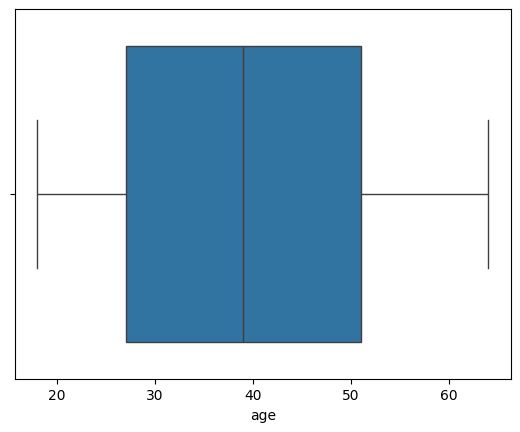

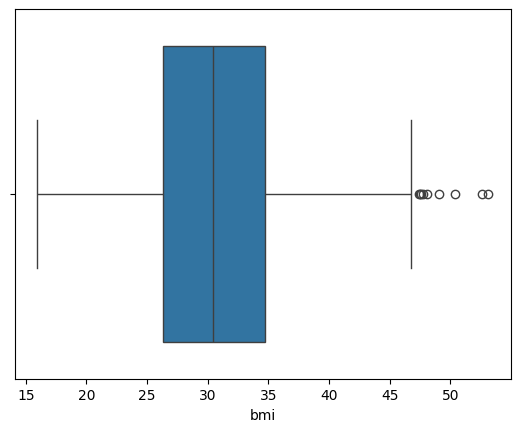

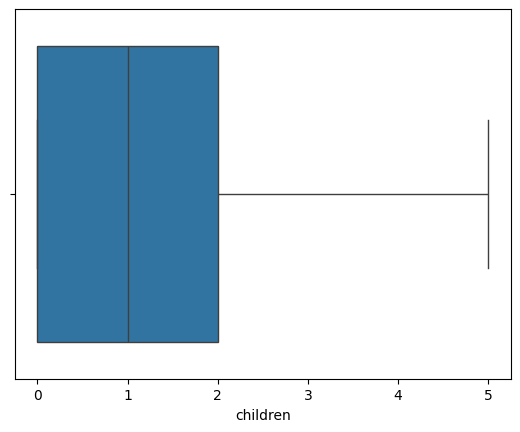

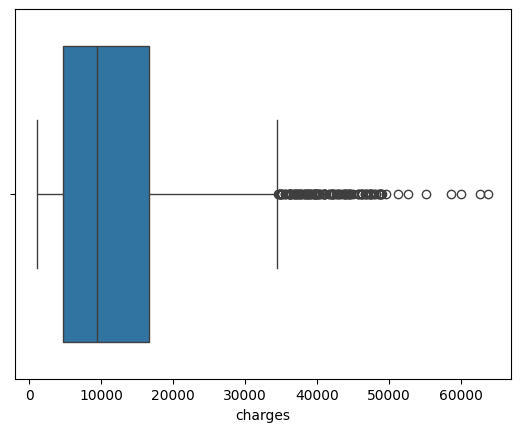

In [420]:
for column in numeric_columns:
    sns.boxplot(x=df1[column])
    plt.show()

In [421]:
def detect_outliers(col):
    Q1,Q3=df1[col].quantile([0.25,0.82])
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    return lower_bound,upper_bound

In [422]:
detect_outliers("charges")

(-21031.69838199999, 47709.74796999999)

In [423]:
df1=df1[df1.charges<detect_outliers("charges")[1]]
df1.describe()

,age,bmi,children,charges
count,1319.000000,1319.000000,1319.000000,1319.000000
mean,39.038666,30.566816,1.099318,12748.777382
std,13.989022,6.068832,1.208213,11286.208421
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.210000,0.000000,4703.000275
50%,39.000000,30.210000,1.000000,9264.797000
75%,51.000000,34.430000,2.000000,15819.342350
max,64.000000,53.130000,5.000000,47496.494450


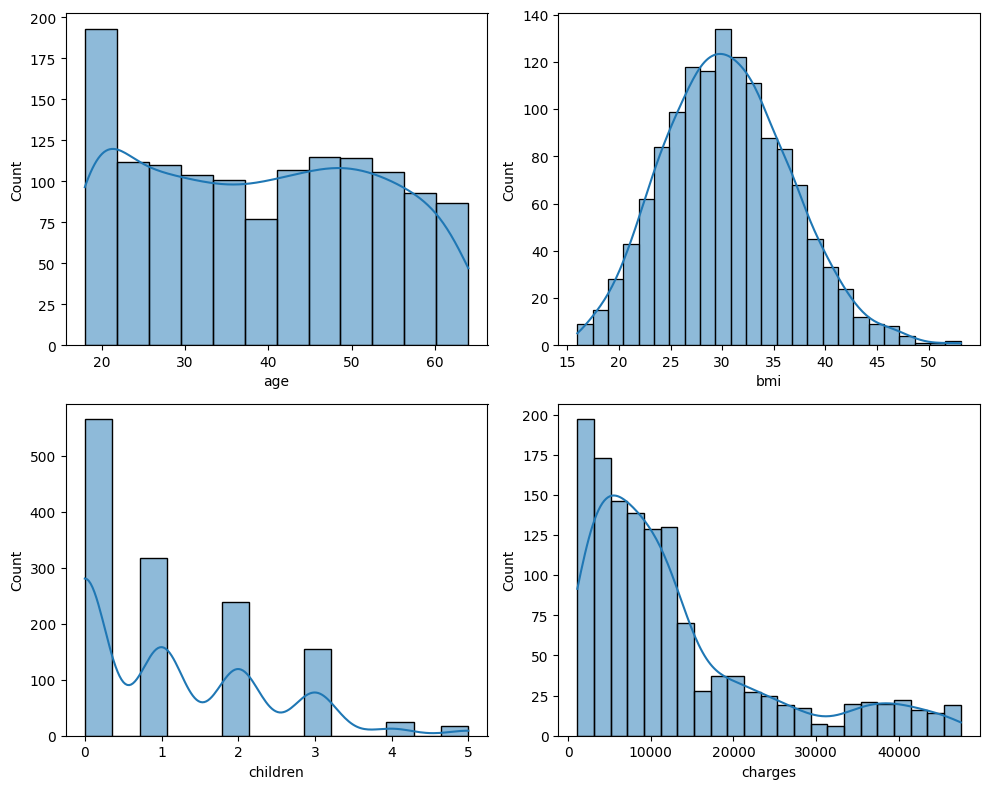

In [424]:
fig,axs=plt.subplots(2,2,figsize=(10,8))
for i,col in enumerate(numeric_columns):
    ax=axs[i//2,i%2]
    sns.histplot(df1[col],kde=True,ax=ax)
plt.tight_layout()
plt.show()

In [425]:
categorical_cols=df1.select_dtypes("object").columns
for col in categorical_cols:
    print(f"{col}: {df1[col].unique()}")

sex: ['female' 'male']
smoker: ['yes' 'no']
region: ['southwest' 'southeast' 'northwest' 'northeast']


In [426]:
pct_sex=df1["smoker"].value_counts(normalize=True)

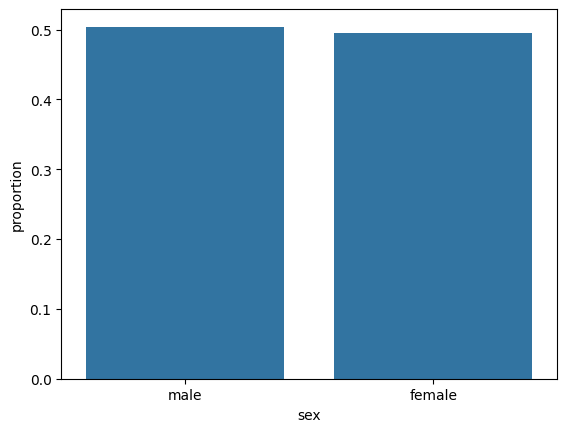

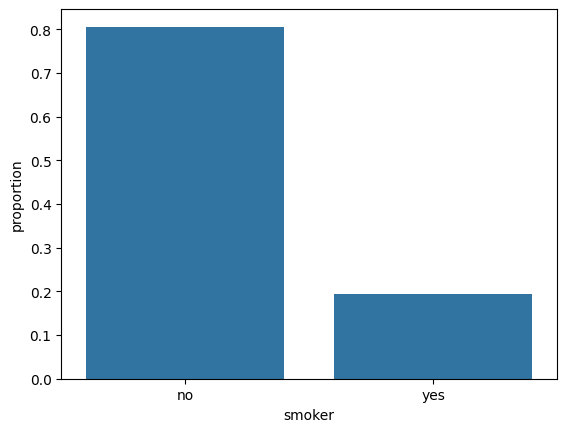

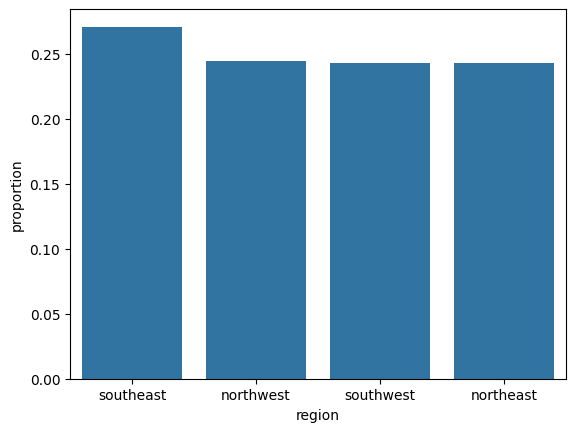

In [427]:
for col in categorical_cols:
    pct_dist=df1[col].value_counts(normalize=True)
    sns.barplot(pct_dist)
    plt.show()

In [428]:
crosstab=pd.crosstab(df1.sex,df1.smoker)
crosstab

smoker,no,yes
sex,,
female,547,107
male,516,149


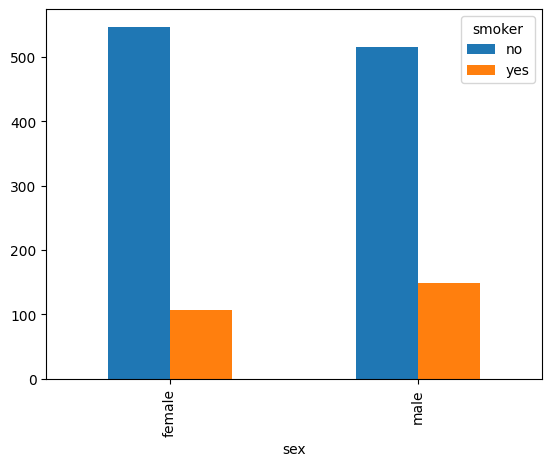

In [429]:
crosstab.plot(kind="bar")
plt.show()

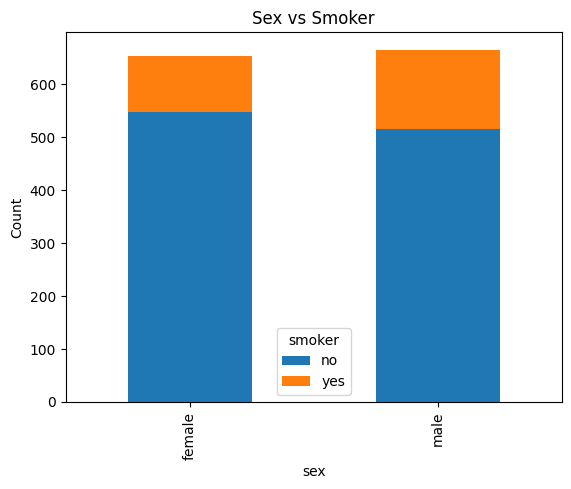

In [430]:
crosstab.plot(kind="bar",stacked=True)
plt.title("Sex vs Smoker")
plt.ylabel("Count")
plt.show()

<Axes: xlabel='smoker', ylabel='sex'>

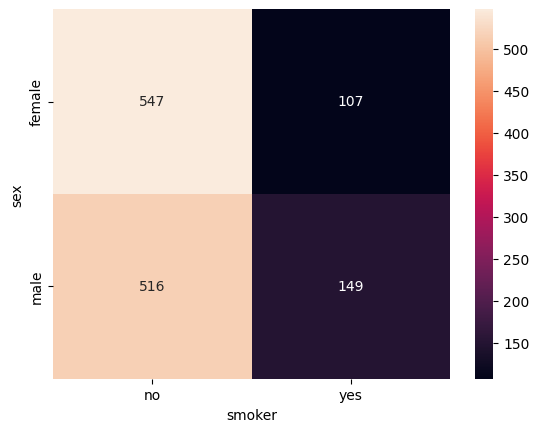

In [431]:
sns.heatmap(crosstab,annot=True,fmt="d")

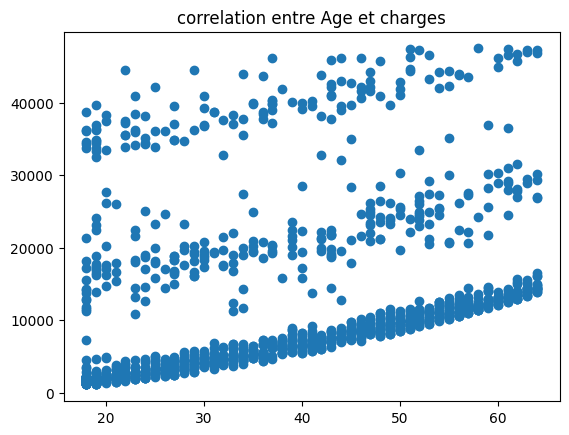

In [432]:
plt.scatter(x=df1.age,y=df1.charges)
plt.title("correlation entre Age et charges",)
plt.show()

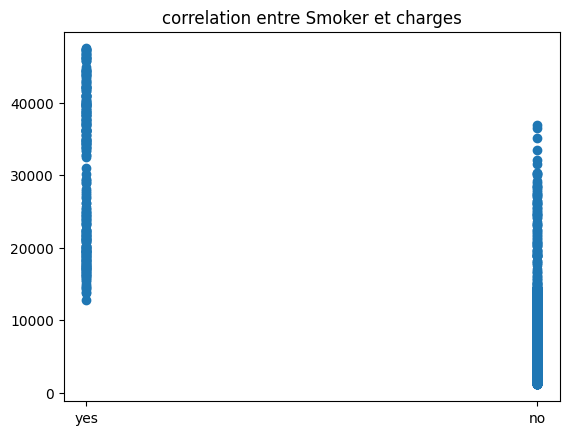

In [433]:
plt.scatter(x=df1.smoker,y=df1.charges)
plt.title("correlation entre Smoker et charges",)
plt.show()

In [434]:
sns.heatmap(df1.corr(),annot=True)
plt.show()

ValueError: could not convert string to float: 'female'

### Encodage

In [435]:
df1_encoded=pd.get_dummies(df1,columns=["sex","smoker","region"],dtype=int)

df1_encoded.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,0,0,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0,0,0,1,0
2,28,33.000,3,4449.46200,0,1,1,0,0,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0,1,0,0


In [436]:
X=df1_encoded.drop("charges",axis=1)
y=df1_encoded["charges"]
X.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,1,0,0,1,0,0,0,1
1,18,33.770,1,0,1,1,0,0,0,1,0
2,28,33.000,3,0,1,1,0,0,0,1,0
3,33,22.705,0,0,1,1,0,0,1,0,0
4,32,28.880,0,0,1,1,0,0,1,0,0


### Normalisation

In [450]:
from sklearn.preprocessing import StandardScaler

In [451]:
df1_encoded[["age","bmi","children","charges"]].describe()

,age,bmi,children,charges
count,1319.000000,1319.000000,1319.000000,1319.000000
mean,39.038666,30.566816,1.099318,12748.777382
std,13.989022,6.068832,1.208213,11286.208421
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.210000,0.000000,4703.000275
50%,39.000000,30.210000,1.000000,9264.797000
75%,51.000000,34.430000,2.000000,15819.342350
max,64.000000,53.130000,5.000000,47496.494450


In [452]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=5)
scaler=StandardScaler()
X_train[["age","bmi","children"]]=scaler.fit_transform(X_train[["age","bmi","children"]])
X_test[["age","bmi","children"]]=scaler.transform(X_test[["age","bmi","children"]])
X_test


,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
977,-0.936424,-0.220144,-0.071252,0,1,1,0,0,0,1,0
707,0.713470,-0.295306,1.599201,0,1,1,0,0,1,0,0
383,-0.290814,2.098424,0.763975,1,0,1,0,0,0,1,0
168,-1.438566,0.216936,-0.071252,1,0,1,0,0,1,0,0
604,-1.438566,-0.357396,-0.906478,1,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
210,-1.366832,0.408925,-0.071252,0,1,1,0,0,0,0,1
391,-1.438566,1.132762,-0.906478,1,0,1,0,0,1,0,0
877,-0.434283,0.480818,3.269653,0,1,1,0,0,0,1,0
454,-0.506017,2.619653,0.763975,0,1,1,0,0,0,1,0


### Entraînement des Modèles de Régression

In [453]:
X_train

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
431,-0.721221,-1.676807,0.763975,1,0,1,0,0,1,0,0
310,0.785204,-0.636800,-0.906478,0,1,1,0,0,0,0,1
426,-0.075610,-0.528143,-0.071252,1,0,1,0,1,0,0,0
587,-0.362548,-0.046946,-0.071252,1,0,0,1,0,1,0,0
1140,0.785204,1.073940,-0.071252,0,1,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
75,1.287346,0.573953,-0.906478,0,1,1,0,0,1,0,0
1158,-1.366832,0.015144,-0.906478,1,0,1,0,1,0,0,0
1012,1.574284,0.462845,2.434427,1,0,1,0,0,0,1,0
209,0.067859,1.753662,-0.071252,0,1,1,0,1,0,0,0


#### Linear Regression

In [454]:
model_LR=LinearRegression()
model_LR.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [455]:
print(f"Coeficient: {model_LR.coef_}, Intercept: {model_LR.intercept_}")

Coeficient: [  3517.23399758   1953.09964333    660.76342537     29.18091301
    -29.18091301 -11287.54861925  11287.54861925    591.26751616
    201.12158235   -328.57292184   -463.81617667], Intercept: 19777.482454698307


In [456]:
predictions_test=model_LR.predict(X_test)
predictions_train=model_LR.predict(X_train)

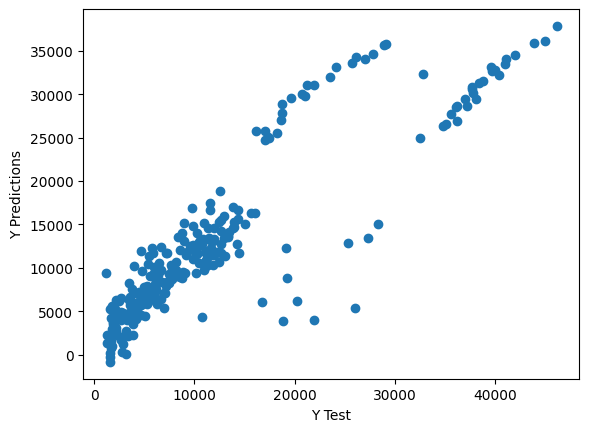

In [457]:
plt.scatter(y_test,predictions_test)
plt.xlabel("Y Test")
plt.ylabel("Y Predictions")
plt.show()

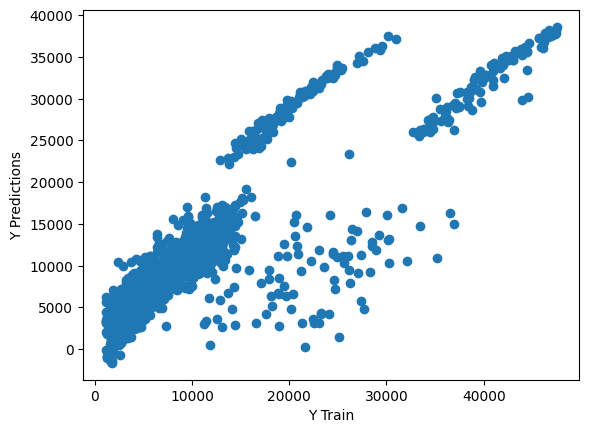

In [458]:
plt.scatter(y_train,predictions_train)
plt.xlabel("Y Train")
plt.ylabel("Y Predictions")
plt.show()

#### Model Evalution

In [459]:
print(f"MSE of Test data: {mean_squared_error(y_test,predictions_test)}")
print(f"MAE of Test data: {mean_absolute_error(y_test,predictions_test)}")

MSE of Test data: 24498857.93546539
MAE of Test data: 3541.553764455197


In [460]:
print(f"R2 value of Test data: {r2_score(y_test,predictions_test)}")
print(f"R2 value of Train data: {r2_score(y_train,predictions_train)}")

R2 value of Test data: 0.7852578663258739
R2 value of Train data: 0.7278752370157371


#### R2 de Test est plus grande que la Valeur R2 de Train
#### aucune signe de overfitting ou uderfitting

#### System charge prediction

In [461]:
nouveau_patient={
    "age":19,
    "bmi":27.900,
    "children":0,
    "sex":"female",
    "smoker":"yes",
    "region":"southwest"
}
patient_data=pd.DataFrame([nouveau_patient])
patient_data = pd.get_dummies(patient_data, columns=["sex","smoker","region"], dtype=int)
patient_data = patient_data.reindex(columns=model_LR.feature_names_in_, fill_value=0)
print(patient_data)



   age   bmi  children  sex_female  sex_male  smoker_no  smoker_yes  \
0   19  27.9         0           1         0          0           1   

   region_northeast  region_northwest  region_southeast  region_southwest  
0                 0                 0                 0                 1  


In [462]:
patient_data[["age", "bmi", "children"]] = scaler.transform(patient_data[["age", "bmi", "children"]])
print(patient_data)

        age       bmi  children  sex_female  sex_male  smoker_no  smoker_yes  \
0 -1.438566 -0.424387 -0.906478           1         0          0           1   

   region_northeast  region_northwest  region_southeast  region_southwest  
0                 0                 0                 0                 1  


In [463]:
prediction = model_LR.predict(patient_data)

In [464]:
print('The insurance cost is USD ', prediction[0])

The insurance cost is USD  24142.783842263358


### Random Forest Regressor

In [124]:
model_RF=RandomForestRegressor()

In [125]:
model_RF.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [127]:
predict_RF_test=model_RF.predict(X_test)
predict_RF_train=model_RF.predict(X_train)

In [130]:
print(f"MSE of Test data: {mean_squared_error(y_test,predict_RF_test)}")

MSE of Test data: 18514628.396030243


#### System charge prediction

In [129]:
print(f"R2 value of Test data: {r2_score(y_test,predict_RF_test)}")
print(f"R2 value of Train data: {r2_score(y_train,predict_RF_train)}")

R2 value of Test data: 0.8425783791707993
R2 value of Train data: 0.9748795555938067


In [131]:
models_metrics={
    "LinearRegression":[]
}

### Pipeline complet

In [498]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline

numerical_features=["age", "bmi", "children"]
categorical_features=["sex", "smoker", "region"]
preprocessor_LR=ColumnTransformer([
    ("numerical",StandardScaler(),numerical_features),
    ("categorical",OneHotEncoder(dtype=int),categorical_features)
])

In [499]:
pipeline_LR=make_pipeline(preprocessor_LR,LinearRegression())
pipeline_LR

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [500]:
X=df1.drop("charges",axis=1)
y=df1["charges"]
X.head()


,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [501]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline_LR.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [508]:
y_prediction_LR=pipeline_LR.predict(X_test)

In [520]:
r2_score(y_test,y_prediction)
print(f"R2 of Test data: {r2_score(y_test,y_prediction_LR)}")
print(f"MSE of Test data: {np.sqrt(mean_squared_error(y_test,y_prediction_LR))}")
print(f"MAE of Test data: {mean_absolute_error(y_test,y_prediction_LR)}")

R2 of Test data: 0.7445440477203232
MSE of Test data: 5559.433948190077
MAE of Test data: 3951.2573881383396


### systeme de prediction

In [521]:
nouveau_patient={
    "age":19,
    "bmi":27.900,
    "children":0,
    "sex":"female",
    "smoker":"yes",
    "region":"southwest"
}
patient_data=pd.DataFrame([nouveau_patient])
prediction=pipeline_LR.predict(patient_data)
prediction

array([24711.90377377])

### Random Forest Regressor

In [522]:
preprocessor_RF=ColumnTransformer([
    ("numerical","passthrough",numerical_features),
    ("categorical",OneHotEncoder(dtype=int),categorical_features)
])
pipeline_RF=make_pipeline(
    preprocessor_RF,
    RandomForestRegressor(  n_estimators=100,
        max_depth=None,
        random_state=422)
)

In [523]:
pipeline_RF.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('randomforestregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [524]:
y_prediction_RF=pipeline_RF.predict(X_test)

In [525]:
print(f"R2 of Test data: {r2_score(y_test,y_prediction_RF)}")
print(f"RMSE of Test data: {np.sqrt(mean_squared_error(y_test,y_prediction_RF))}")
print(f"MAE of Test data: {mean_absolute_error(y_test,y_prediction_RF)}")

R2 of Test data: 0.8434633343172292
RMSE of Test data: 4351.916970478618
MAE of Test data: 2469.173565612974


In [526]:
prediction=pipeline_RF.predict(patient_data)

In [550]:
pipeline_RF.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('numerical', 'passthrough',
                                    ['age', 'bmi', 'children']),
                                   ('categorical',
                                    OneHotEncoder(dtype=<class 'int'>),
                                    ['sex', 'smoker', 'region'])])),
  ('randomforestregressor', RandomForestRegressor(random_state=422))],
 'transform_input': None,
 'verbose': False,
 'columntransformer': ColumnTransformer(transformers=[('numerical', 'passthrough',
                                  ['age', 'bmi', 'children']),
                                 ('categorical',
                                  OneHotEncoder(dtype=<class 'int'>),
                                  ['sex', 'smoker', 'region'])]),
 'randomforestregressor': RandomForestRegressor(random_state=422),
 'columntransformer__force_int_remainder_cols': 'deprecated',
 'columntransformer__n_jobs': None,
 'columntransform

prediction

In [542]:
param_grid_RF = {
    "randomforestregressor__n_estimators":  [100, 200, 300,350,400],
    "randomforestregressor__max_depth":     [None, 5, 10, 20],
    "randomforestregressor__min_samples_split": [2, 3,5, 8,10]
}
grid_RF=GridSearchCV(pipeline_RF,param_grid=param_grid_RF,cv=5,scoring="r2")

In [545]:
grid_RF.fit(X_train,y_train)

,estimator,Pipeline(step..._state=422))])
,param_grid,"{'randomforestregressor__max_depth': [None, 5, ...], 'randomforestregressor__min_samples_split': [2, 3, ...], 'randomforestregressor__n_estimators': [100, 200, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numerical', ...), ('categorical', ...)]"


In [546]:
print(f"Meilleurs paramètres RF : {grid_RF.best_params_}")
print(f"Meilleur score CV (R2)  : {grid_RF.best_score_}")

Meilleurs paramètres RF : {'randomforestregressor__max_depth': 5, 'randomforestregressor__min_samples_split': 2, 'randomforestregressor__n_estimators': 300}
Meilleur score CV (R2)  : 0.8359243893102211


In [547]:
grid_RF.best_estimator_

,steps,"[('columntransformer', ...), ('randomforestregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [540]:
best_pipeline=grid_RF.best_estimator_

In [551]:
best_pipeline.predict(patient_data)

array([17969.89113622])

In [552]:
grid_RF.score(X_test,y_test)

0.8722024204845229

### XGBoost Regressor

In [558]:
from xgboost import XGBRegressor

In [559]:
preprocessor_XGB= ColumnTransformer([
    ("numerical","passthrough",numerical_features),
    ("categorical",OneHotEncoder(dtype=int),categorical_features)
])
pipeline_XGB=make_pipeline(
    preprocessor_XGB,
    XGBRegressor()
)

In [560]:
param_grid_XGB = {
   "xgbregressor__n_estimators":     [100, 200, 300],
    "xgbregressor__max_depth":        [3, 5, 7],
    "xgbregressor__learning_rate":    [0.01, 0.1, 0.2],
    "xgbregressor__subsample":        [0.8, 1.0]
}
grid_XGB=GridSearchCV(pipeline_XGB,param_grid=param_grid_XGB,cv=5,scoring="r2")

In [561]:
grid_XGB.fit(X_train,y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'xgbregressor__learning_rate': [0.01, 0.1, ...], 'xgbregressor__max_depth': [3, 5, ...], 'xgbregressor__n_estimators': [100, 200, ...], 'xgbregressor__subsample': [0.8, 1.0]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numerical', ...), ('categorical', ...)]"


In [563]:
grid_XGB.best_estimator_

,steps,"[('columntransformer', ...), ('xgbregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [565]:
grid_XGB.score(X_test,y_test)

0.869459265578299

In [566]:
grid_XGB.predict(patient_data)

array([17965.934], dtype=float32)

In [567]:
import joblib

In [568]:
joblib.dump(grid_XGB, "model_xgb.pkl")

['model_xgb.pkl']

In [569]:
model=joblib.load("model_xgb.pkl")

In [570]:
model.predict(X)

array([17965.934 ,  4584.175 ,  7061.558 , ...,  3953.3718,  3731.5115,
       27278.791 ], shape=(1319,), dtype=float32)